# Conflict vs PSE — low audio-noise subset

Fits psychometric curves on the fly to:
1. Real per-participant data **filtered to audNoise = 0.1**
2. Simulated data from low-noise model fits in `simulated_data_byNoise/low/`

then plots PSE shift (ms) vs cue conflict (ms), mean ± SEM across n=11 participants.

Single panel since the dataset has only one audio-noise level by construction.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns

import loadData
from fitMainClass import fitPychometric as fitPsychometric

In [2]:
FONT = 18
plt.rcParams.update({
    'font.size': FONT, 'axes.labelsize': FONT, 'axes.titlesize': FONT + 2,
    'xtick.labelsize': FONT, 'ytick.labelsize': FONT, 'legend.fontsize': FONT,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 1.5, 'lines.linewidth': 2.0, 'lines.markersize': 8,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.major.size': 6, 'ytick.major.size': 6,
    'legend.frameon': True, 'legend.framealpha': 0.8, 'legend.edgecolor': 'black',
    'figure.dpi': 100, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
    'axes.grid': False,
})

## 1. Config

In [3]:
STANDARD_S = 0.5
NOISE_LABEL = 'low'
NOISE_VALUE = 0.1

PIDS = ['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']

SIM_ROOT = f'simulated_data_byNoise/{NOISE_LABEL}'
MODEL_SUFFIX = 'LapseFix_sharedPrior'
MODELS = {
    'fusionOnlyLogNorm': 'Forced fusion',
    'lognorm':           'Causal-inference averaging',
    'switchingFree':     'Probabilistic cue switching',
}
MODEL_STYLE = {
    'fusionOnlyLogNorm': dict(ls='--', mk='s', color='#2ca02c'),
    'lognorm':           dict(ls='-',  mk='o', color='#600c70'),
    'switchingFree':     dict(ls=':',  mk='^', color='#080529'),
}
DATA_COLOR = '#d62728'  # red used for low-noise data in the original plot

N_STARTS = 3  # psychometric fitter starting points (kept small — psychometric fits are convex-ish)


def logpse_to_shift_s(mu_log, standard_s=STANDARD_S):
    """log-ratio mu  ->  PSE shift in seconds."""
    return (np.exp(mu_log) - 1) * standard_s

## 2. Fit helper

In [4]:
def fit_psychometric_and_extract_mu(data, nStarts=N_STARTS):
    """Run the joint psychometric fit and return (fitter, mu_dict).

    mu_dict maps conflict (rounded to 3 dp) -> mu in logDurRatio units.
    Works for any single-noise subset (the fitter detects uniqueSensory).
    """
    fitter = fitPsychometric(data, intensityVar='logDurRatio')
    fit = fitter.fitMultipleStartingPoints(data=data, nStart=nStarts)
    params = fit.x
    mu_dict = {}
    noises = sorted(fitter.uniqueSensory)
    if len(noises) != 1:
        # We expect exactly one noise level for the by-noise subset, but stay robust
        # by picking the closest match to NOISE_VALUE.
        noise = noises[np.argmin([abs(n - NOISE_VALUE) for n in noises])]
    else:
        noise = noises[0]
    for conflict in sorted(fitter.uniqueConflict):
        mu = fitter.getParams(params, conflict, noise)[1]
        mu_dict[round(float(conflict), 3)] = float(mu)
    return fitter, mu_dict

## 3. Per-participant PSE for real data (low-noise filtered) and each model

In [ ]:
data_rows = []
model_rows = []
skipped_models = []

for pid in PIDS:
    # Real data — filtered to low noise
    full_data, _ = loadData.loadData(f'{pid}_all.csv', verbose=False)
    real_low = full_data[full_data['audNoise'] == NOISE_VALUE].copy()
    if real_low.empty:
        print(f'  {pid}: no low-noise trials, skipping')
        continue

    _, mu_data = fit_psychometric_and_extract_mu(real_low)
    for conflict, mu in mu_data.items():
        data_rows.append(dict(pid=pid, conflict=conflict, shift_s=logpse_to_shift_s(mu)))

    # Each model's simulated low-noise CSV
    for mname in MODELS:
        sim_path = os.path.join(SIM_ROOT, pid, f'{pid}_{mname}_{MODEL_SUFFIX}_simulated.csv')
        if not os.path.exists(sim_path):
            skipped_models.append((pid, mname, sim_path))
            continue
        sim_df = pd.read_csv(sim_path)
        sim_df['logDurRatio'] = np.log(sim_df['testDurS']) - np.log(sim_df['standardDur'])
        _, mu_model = fit_psychometric_and_extract_mu(sim_df)
        for conflict, mu in mu_model.items():
            model_rows.append(dict(
                pid=pid, model=mname, conflict=conflict,
                shift_s=logpse_to_shift_s(mu),
            ))
    print(f'  {pid}: data + {len(MODELS) - sum(1 for _ in skipped_models if _[0]==pid)} models fit')

data_pid_df = pd.DataFrame(data_rows)
model_pid_df = pd.DataFrame(model_rows)
print(f'\nData rows : {len(data_pid_df)}  (expect {len(PIDS)} pids × n_conflicts)')
print(f'Model rows: {len(model_pid_df)} (expect {len(PIDS)} × {len(MODELS)} × n_conflicts)')
if skipped_models:
    print(f'Missing simulated CSVs: {len(skipped_models)}')
    for pid, mname, path in skipped_models[:5]:
        print(f'  - {pid} / {mname}: {path}')

Fitting multiple starting points:   4%|▎         | 1/27 [00:00<00:16,  1.59it/s]

## 4. Aggregate across participants (mean ± SEM)

In [ ]:
def agg_mean_sem(df, group_cols, value_col='shift_s'):
    g = df.groupby(group_cols)[value_col]
    out = pd.DataFrame({
        'mean': g.mean(),
        'sem':  g.std(ddof=1) / np.sqrt(g.count()),
        'n':    g.count(),
    }).reset_index()
    return out


data_agg = agg_mean_sem(data_pid_df, ['conflict']).sort_values('conflict').reset_index(drop=True)
model_agg = agg_mean_sem(model_pid_df, ['model', 'conflict']).sort_values(['model', 'conflict']).reset_index(drop=True)

print('Data (low noise) — mean ± SEM by conflict (s):')
print(data_agg.round(4).to_string(index=False))
print('\nModel predictions — mean ± SEM by (model, conflict) (s):')
print(model_agg.round(4).to_string(index=False))

Data (low noise) — mean ± SEM by conflict (s):
 conflict    mean    sem  n
    -0.25 -0.0484 0.0291 11
    -0.17 -0.0332 0.0153 11
    -0.08  0.0044 0.0134 11
     0.00 -0.0049 0.0162 11
     0.08  0.0007 0.0166 11
     0.17  0.0261 0.0185 11
     0.25  0.0294 0.0207 11

Model predictions — mean ± SEM by (model, conflict) (s):
            model  conflict    mean    sem  n
fusionOnlyLogNorm     -0.25 -0.0517 0.0180 11
fusionOnlyLogNorm     -0.17 -0.0297 0.0093 11
fusionOnlyLogNorm     -0.08 -0.0028 0.0074 11
fusionOnlyLogNorm      0.00  0.0015 0.0028 11
fusionOnlyLogNorm      0.08  0.0099 0.0046 11
fusionOnlyLogNorm      0.17  0.0193 0.0103 11
fusionOnlyLogNorm      0.25  0.0314 0.0168 11
          lognorm     -0.25 -0.0450 0.0140 11
          lognorm     -0.17 -0.0373 0.0102 11
          lognorm     -0.08 -0.0182 0.0056 11
          lognorm      0.00 -0.0024 0.0046 11
          lognorm      0.08  0.0096 0.0050 11
          lognorm      0.17  0.0243 0.0082 11
          lognorm      0.25

## 5. Single-panel conflict-vs-PSE plot

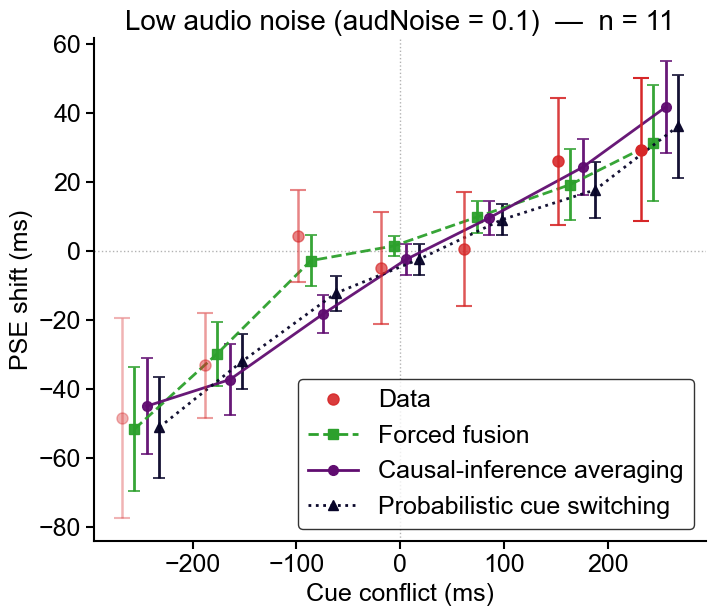

Saved: conflictVsPSE_lowNoise.[pdf|svg|png]


In [ ]:
def plot_low_noise_conflict_vs_pse(data_agg, model_agg, save_prefix='conflictVsPSE_lowNoise'):
    fig, ax = plt.subplots(figsize=(7.5, 6.5))

    model_names = list(MODELS.keys())
    all_series = ['__data__'] + model_names
    mid = (len(all_series) - 1) / 2
    offsets = {s: (i - mid) * 12.0 for i, s in enumerate(all_series)}  # ms shift per series

    # --- data points with SEM
    sd = data_agg.sort_values('conflict')
    x = sd['conflict'].to_numpy(float) * 1000
    y = sd['mean'].to_numpy(float) * 1000
    yerr = sd['sem'].to_numpy(float) * 1000

    base_rgb = mcolors.to_rgb(DATA_COLOR)
    alphas = np.linspace(0.35, 1.0, len(x))
    for k in range(len(x)):
        rgba = (*base_rgb, alphas[k])
        ax.errorbar(x[k] + offsets['__data__'], y[k],
                    yerr=[[yerr[k]], [yerr[k]]],
                    color=rgba, fmt='o', capsize=6, lw=1.8,
                    capthick=1.5, markersize=8, zorder=6,
                    markeredgecolor=rgba)

    # --- each model's predictions with SEM, connected by line
    for mname in model_names:
        sub = model_agg[model_agg['model'] == mname].sort_values('conflict')
        if sub.empty:
            continue
        xm = sub['conflict'].to_numpy(float) * 1000 + offsets[mname]
        ym = sub['mean'].to_numpy(float) * 1000
        yerr_m = sub['sem'].to_numpy(float) * 1000
        style = MODEL_STYLE[mname]
        ax.errorbar(xm, ym, yerr=yerr_m,
                    color=style['color'], ls=style['ls'], marker=style['mk'],
                    lw=2.0, markersize=7, capsize=4, capthick=1.2, alpha=0.95,
                    zorder=4)

    # Unity reference (positive conflict = test should be perceived shorter, etc.)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.0, alpha=0.6, zorder=1)
    ax.axvline(0, color='gray', linestyle=':', linewidth=1.0, alpha=0.6, zorder=1)

    ax.set_xlabel('Cue conflict (ms)')
    ax.set_ylabel('PSE shift (ms)')
    ax.set_title(f'Low audio noise (audNoise = {NOISE_VALUE})  —  n = {data_agg["n"].max() if "n" in data_agg else len(PIDS)}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    handles = [Line2D([0], [0], color=(*base_rgb, 0.9), marker='o', lw=0,
                      markersize=8, markeredgecolor=(*base_rgb, 0.9), label='Data')]
    labels = ['Data']
    for mname in model_names:
        style = MODEL_STYLE[mname]
        handles.append(Line2D([0], [0], color=style['color'], ls=style['ls'],
                              marker=style['mk'], lw=2, markersize=7,
                              label=MODELS[mname]))
        labels.append(MODELS[mname])
    ax.legend(handles=handles, labels=labels, loc='best', frameon=True)

    plt.tight_layout()
    plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    plt.savefig(f'{save_prefix}.svg', format='svg', bbox_inches='tight')
    plt.savefig(f'{save_prefix}.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_prefix}.[pdf|svg|png]')


plot_low_noise_conflict_vs_pse(data_agg, model_agg)

## 6. Per-participant scatter (optional sanity check)

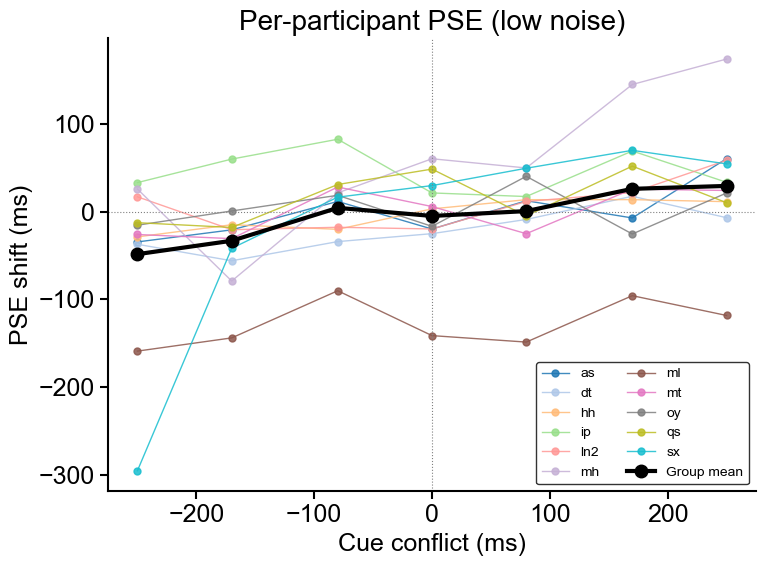

In [ ]:
def plot_per_pid_overlay(data_pid_df, save_prefix='conflictVsPSE_lowNoise_perPid'):
    fig, ax = plt.subplots(figsize=(8, 6))
    pids = sorted(data_pid_df['pid'].unique())
    cmap = plt.get_cmap('tab20')
    for i, pid in enumerate(pids):
        sub = data_pid_df[data_pid_df['pid'] == pid].sort_values('conflict')
        ax.plot(sub['conflict'] * 1000, sub['shift_s'] * 1000,
                marker='o', lw=1.0, ms=5, color=cmap(i / len(pids)),
                label=pid, alpha=0.85)
    # Group mean
    grp = data_pid_df.groupby('conflict')['shift_s'].mean().sort_index()
    ax.plot(grp.index * 1000, grp.values * 1000, color='black', lw=3,
            marker='o', ms=9, label='Group mean', zorder=10)
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.axvline(0, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('Cue conflict (ms)')
    ax.set_ylabel('PSE shift (ms)')
    ax.set_title(f'Per-participant PSE (low noise)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=10, ncol=2, loc='best', frameon=True)
    plt.tight_layout()
    plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    plt.savefig(f'{save_prefix}.png', dpi=200, bbox_inches='tight')
    plt.show()


plot_per_pid_overlay(data_pid_df)